In [4]:
import warnings
warnings.filterwarnings("ignore", message="MatMul8bitLt: inputs will be cast.*")

In [5]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import login


login(os.getenv('HUGGINGFACE_HUB_TOKEN',"Env Key Error!"))
print("Logged In...!")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device {device} is in use")


Logged In...!
Device cuda is in use


In [6]:
# Define the model famil and model name
ModelFamily = "meta-llama"
ModelName = "Llama-3.2-11B-Vision-Instruct"

# Read content from a local file
image_path = os.path.join(os.getcwd() + "/BFI_image_inventory.jpg")

# Loading a local image                          
input_image = "file:///" + image_path
                         
image_prompt = """There are 44 questions in this test and their respective scale.
  extract each statement number and statement pairs.
  Answer every questions and reply your answers in the given scale which is 1 to 5.
  Your response is only should be in numbers. your response must be in json format.
  json respone must have following fields statement number, statement and your answer.
  """

print("Using Image : " + input_image)

Using Image : file:////mnt/primary/PersonalityChat/multimodal/BFI_image_inventory.jpg


### Quantized Llama-3.2-11B-Vision-Instruct

In [4]:
from PIL import Image
from transformers import AutoProcessor, BitsAndBytesConfig
from transformers import MllamaForConditionalGeneration

model_id = f"{ModelFamily}/{ModelName}"

# ---- 4-bit quantization config (saves VRAM) ----
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                 # 4-bit weights
    bnb_4bit_quant_type="nf4",         # best quality for 4-bit
    bnb_4bit_use_double_quant=True,    # extra quantization stage to cut memory
    bnb_4bit_compute_dtype=torch.bfloat16,  # compute in bf16 if your GPU supports it; else use float16
)

# ---- Processor (tokenizer + vision preproc) ----
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

# ---- Model (multimodal) ----
model = MllamaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16, # or torch.float16 if needed
    device_map="auto", # shard across GPU/CPU if VRAM is tight
    trust_remote_code=True,
)

# ---- Load BFI image ----
img = Image.open(image_path).convert("RGB")

# ---- Build a multimodal chat turn (image + text) ----
messages = [
    {
        "role": "system",
        "content": [
            {"type": "text", "text": (
                "You are a helpful vision assistant."
                "You will answer to user questions requested format, your response must have the requested answers only."
            )},
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "image"},  # slot for the image we pass below
            {"type": "text", "text": {image_prompt}},
        ],
    }
]

# Turn the chat into a text prompt that the model expects
prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=False,
)

# Pack text + image into tensors
inputs = processor(
    text=prompt,
    images=[img],
    add_special_tokens=False,
    return_tensors="pt",
).to(model.device)

# Move to devices chosen by device_map
# inputs = {k: (v.to(model.device) if hasattr(v, "to") else v) for k, v in inputs.items()}


The model weights are not tied. Please use the `tie_weights` method before using the `infer_auto_device` function.


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [9]:
def get_response_from_img():
    with torch.inference_mode():
        output = model.generate(**inputs,
                                do_sample=False,
                                temperature=0.0,
                                top_p=0.0,
                                max_new_tokens=2048)
        # print(processor.decode(output[0]))

        # Decode only the newly generated portion
        new_tokens = output[0, inputs["input_ids"].shape[-1]:]
        output_text = processor.decode(new_tokens, skip_special_tokens=True)
        return output_text

In [6]:
# Test
# response = get_response_from_img()
# print(response)

### Record the responses

In [7]:
iterations = 10
os.makedirs(f"{ModelFamily}/responses/", exist_ok=True)

In [ ]:
# Get model respones for number of iterations
for i in range(iterations):
    # Removed temperature and top_p arguments
    response = get_response_from_img()
    if response is not None:
      fname = f'{ModelFamily}/responses/response_{i+1}.json'
      response = response.replace("```json", "").replace("```","")
    with open(fname, 'w') as log_file:
      log_file.write(response)

/opt/miniconda3/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/opt/miniconda3/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


### Process the responses

In [8]:
# process the responses
reversed_questions = [6, 21, 31, 2, 12, 27, 37, 8, 18, 23, 43, 9, 24, 34, 35, 41 ]
reverse_score = { 1: 5, 2: 4, 3: 3, 4: 2, 5: 1 }

def process_folders(bfi_df, responses_dir):
    for fname in os.listdir(responses_dir):
        if fname.endswith('.json'):
            print(f"Processing file: {fname}")
            col = len(bfi_df.columns) - 1
            with open(os.path.join(responses_dir, fname), 'r') as f:
                data = json.load(f)
                for response in data:
                    if response.get('statement_number'):
                        q_num = int(response.get('statement_number'))
                    else:
                        q_num = int(response.get('statement number'))
                    resp_val = int(response.get('answer'))
                    if resp_val in reversed_questions:
                        resp_val = reverse_score.get(resp_val, 0)
                    bfi_df.loc[bfi_df["qno"] == q_num, f"response_{col}"] = resp_val     
    return bfi_df

input_csv = os.path.join(os.getcwd(), 'bfi_input_df.csv')
responses_dir = os.path.join(os.getcwd(),f'{ModelFamily}','Llama3.2', 'responses')
output_csv = os.path.join(responses_dir, 'bfi_all_responses.csv')

bfi_df = pd.read_csv(input_csv)

bfi_response_data = process_folders(bfi_df, responses_dir)

bfi_response_data.to_csv(output_csv, index=False)

Processing file: response_7.json
Processing file: response_5.json
Processing file: response_8.json
Processing file: response_10.json
Processing file: response_2.json
Processing file: response_1.json
Processing file: response_4.json
Processing file: response_6.json
Processing file: response_9.json
Processing file: response_3.json


In [9]:
def draw_polar_chart(data_frame, title, color='blue'):
    llm_scores = data_frame.get('avg_score')
    categories = list(llm_scores.keys())
    values = list(llm_scores.values())
    xticks_labels = [f"{label}\n({val})" for label, val in zip(categories, values)]
    
    values += values[:1]
    
    # compute angle for each category
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] 
    
    #draw polar chart
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, linewidth=1, linestyle='solid',color=color)
    ax.fill(angles, values, color=color, alpha=0.10)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(xticks_labels,  size=10)
    
    ax.set_ylim(1,5)
    ax.set_rgrids([1, 2, 3, 4, 5], labels=[])
    ax.grid(True)

    plt.title(title.replace('_',' '), size=14, pad=50)
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"{title}_chart.png", dpi=300, bbox_inches='tight')

In [10]:
category_names = {
    'E': "Extraversion",
    'A': "Agreeableness",
    'C': "Conscientiousness",
    'N': "Neuroticism",
    'O': "Openness"
}

bfi_response = pd.read_csv(output_csv)

# Merge all response columns by their average into a single column
response_cols = [col for col in bfi_response.columns if col.startswith("response_")]
bfi_response["response"] = bfi_response[response_cols].mean(axis=1)

llm_scores = pd.DataFrame(columns=["Dimensions", "avg_score","std_score"])
    
# print("\nAverage response for each category:")
avg_by_category = bfi_response.groupby("category")["response"].mean()
std_by_category = bfi_response.groupby("category")["response"].std()

for category in avg_by_category.index:
    # add the average score to the table
    avg = avg_by_category[category]
    std = std_by_category[category]
    llm_scores.loc[len(llm_scores)] = [ category_names.get(category), round(avg,2), round(std,2) ]        
    # print(f"{category_names.get(category)}: \t\t{avg:.2f} ± {std:.2f}")

llm_scores = llm_scores.set_index('Dimensions')

print("---------------------------------------------------------------\n")
print(llm_scores.to_markdown())
print("\n----------------------------END--------------------------------\n")


with open(f"{ModelFamily}/{ModelName}_results.md", "w") as result_file:
        result_file.write(f"# Test information\n")
        result_file.write(f"- Model: **{ModelName}**\n")
        result_file.write(f"- Test type: **Multimodal - Image**\n")
        result_file.write(f"- Response format: **number**\n")
        result_file.write(f"- Shuffle: **NA**\n")
        result_file.write(f"- No of iterations: **{iterations}**\n\n")
        result_file.write("# Model responses for each BFI dimensions:\n\n")
        result_file.write(llm_scores.to_markdown())
        result_file.write("\n\n")
        

---------------------------------------------------------------

| Dimensions        |   avg_score |   std_score |
|:------------------|------------:|------------:|
| Agreeableness     |        1.44 |        0.88 |
| Conscientiousness |        3.11 |        1.27 |
| Extraversion      |        3.5  |        1.2  |
| Neuroticism       |        2.5  |        1.31 |
| Openness          |        2.2  |        1.55 |

----------------------------END--------------------------------



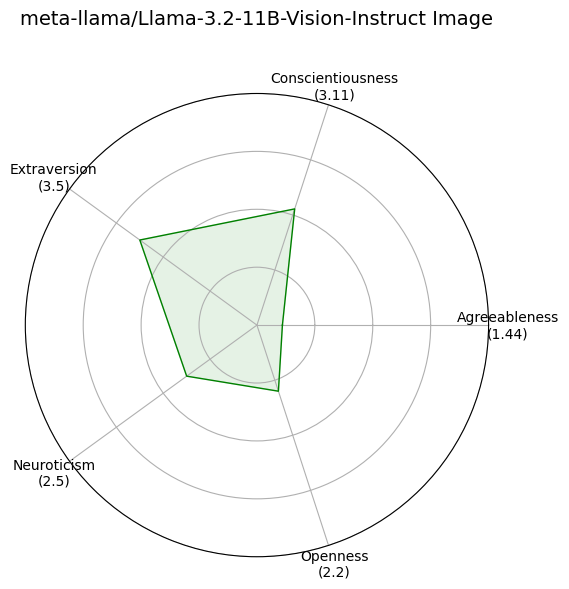

In [11]:
# Draw polar chart
draw_polar_chart(llm_scores.to_dict(), f"{ModelFamily}/{ModelName}_Image", color='green')

# Cleaning 

In [ ]:
# import gc
# gc.collect()
# torch.cuda.empty_cache()
# torch.cuda.ipc_collect()